In [1]:
# system libs
import os, sys, glob
import datetime
import xarray as xr    
import matplotlib.pyplot as plt
# array operators and netcdf datasets
import numpy as np
import xarray as xr
xr.set_options(keep_attrs=True)
import pandas as pd
from scipy.spatial.distance import pdist

# to have tools to format time
sys.path.append( '/work/bb1224/2024_MS-COURSE/tools/analysis' )
from tools import convert_timevec

import warnings
warnings.simplefilter("ignore")


## re-load data as nested dicts

 re-load data as nested dicts: 
- Mask_fields[case][dom]
- Mask_fields_filtered[case][dom]
- Features_fields[case][dom]
- Features_fields_filtered[case][dom]

In [2]:
#re-load data as nested dicts
def load_fields(base_mask_path="output_masks", base_feat_path="output_features"):
    case_names = ["case1", "case2"]
    dom_names = ["DOM01", "DOM02", "DOM03"]

    Mask_fields = {}
    Mask_fields_filtered = {}
    Features_fields = {}
    Features_fields_filtered = {}

    for case in case_names:
        Mask_fields[case] = {}
        Mask_fields_filtered[case] = {}
        Features_fields[case] = {}
        Features_fields_filtered[case] = {}

        for dom in dom_names:
            mask_file = os.path.join(base_mask_path, f"mask_{case}_{dom}.nc")
            mask_file_filt = os.path.join(base_mask_path, f"mask_filt_{case}_{dom}.nc")
            feat_file = os.path.join(base_feat_path, f"features_{case}_{dom}.csv")
            feat_file_filt = os.path.join(base_feat_path, f"features_filt_{case}_{dom}.csv")
                        
            if os.path.exists(mask_file):
                Mask_fields[case][dom] = xr.load_dataarray(mask_file)

            if os.path.exists(mask_file):
                Mask_fields_filtered[case][dom] = xr.load_dataarray(mask_file_filt)

            if os.path.exists(feat_file):
                Features_fields[case][dom] = pd.read_csv(feat_file)
                
            if os.path.exists(feat_file):
                Features_fields_filtered[case][dom] = pd.read_csv(feat_file_filt)

    return Features_fields, Mask_fields, Mask_fields_filtered, Features_fields_filtered


In [3]:
Features_fields, Mask_fields, Mask_fields_filtered, Features_fields_filtered = load_fields()


# Probability Density Function (PDF)

In [5]:
 def compute_pdf_logbins(sizes, nbins=20):
    """Compute log-binned PDF for a given 1D array of cloud sizes (km²)."""

    # remove zeros and extremely small values
    sizes = sizes[sizes > 0]

    # avoid too-small bins
    if sizes.min() <= 0:
        raise ValueError("sizes contain non-positive values")

    # log-spaced bin edges
    #bin_edges = np.logspace(0, np.log10(sizes.max()), nbins+1)
    bin_edges = np.logspace(np.log10(sizes.min()), np.log10(sizes.max()), nbins+1)

    counts, _ = np.histogram(sizes, bins=bin_edges)
    bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])
    bin_widths  = np.diff(bin_edges)

    pdf = counts / (counts.sum() * bin_widths)

    return bin_centers, pdf

def extract_sizes(features, case, dom):

    sizes = features[case][dom]["size_km2"].to_numpy()
    
    return sizes[sizes > 0]

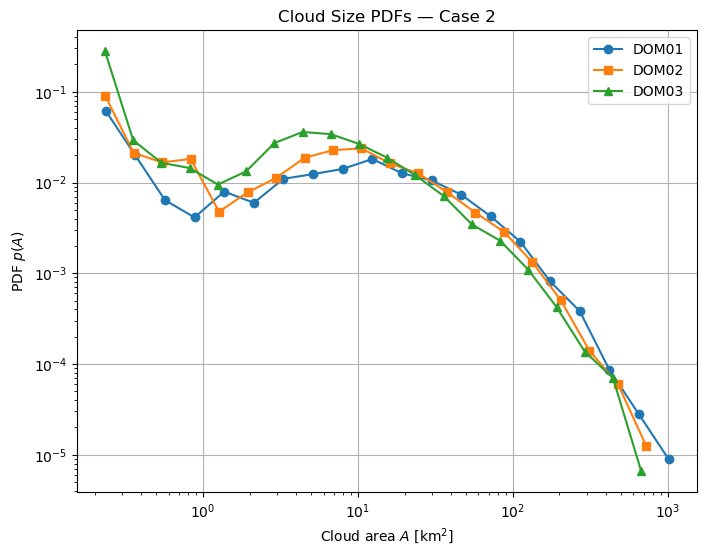

In [6]:
sizes_dom1 = extract_sizes(Features_fields, "case2", "DOM01")
sizes_dom2 = extract_sizes(Features_fields, "case2", "DOM02")
sizes_dom3 = extract_sizes(Features_fields, "case2", "DOM03")

bins = 20
bc1, pdf1 = compute_pdf_logbins(sizes_dom1, nbins=bins)
bc2, pdf2 = compute_pdf_logbins(sizes_dom2, nbins=bins)
bc3, pdf3 = compute_pdf_logbins(sizes_dom3, nbins=bins)


plt.figure(figsize=(8,6))

plt.loglog(bc1, pdf1, marker='o', label="DOM01")
plt.loglog(bc2, pdf2, marker='s', label="DOM02")
plt.loglog(bc3, pdf3, marker='^', label="DOM03")

plt.xlabel("Cloud area $A$ [km$^2$]")
plt.ylabel("PDF $p(A)$")
plt.title("Cloud Size PDFs — Case 2")
plt.legend()
plt.grid(True)


plt.legend()

plt.show()

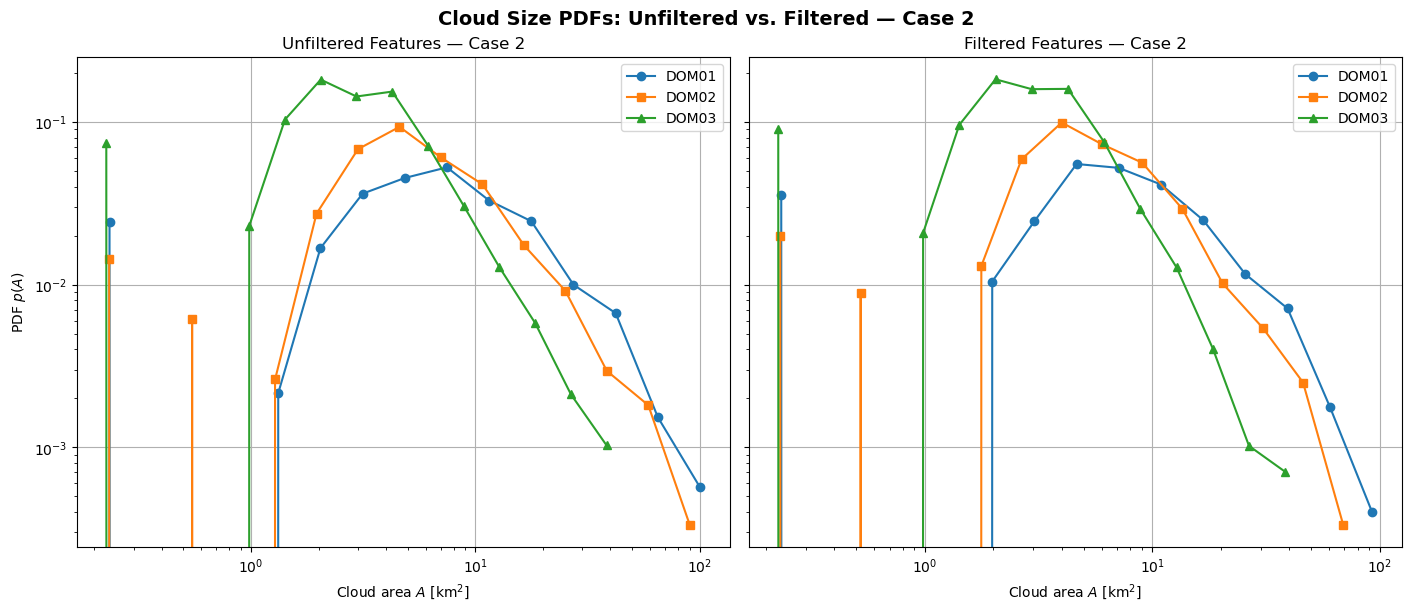

In [7]:
case = "case1"

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharey=True, constrained_layout=True)

# ---- UNFILTERED ----
sizes_dom1 = extract_sizes(Features_fields, case, "DOM01")
sizes_dom2 = extract_sizes(Features_fields, case, "DOM02")
sizes_dom3 = extract_sizes(Features_fields, case, "DOM03")

bc1, pdf1 = compute_pdf_logbins(sizes_dom1, nbins=15)
bc2, pdf2 = compute_pdf_logbins(sizes_dom2, nbins=15)
bc3, pdf3 = compute_pdf_logbins(sizes_dom3, nbins=15)

axs[0].loglog(bc1, pdf1, marker='o', label="DOM01")
axs[0].loglog(bc2, pdf2, marker='s', label="DOM02")
axs[0].loglog(bc3, pdf3, marker='^', label="DOM03")

axs[0].set_xlabel("Cloud area $A$ [km$^2$]")
axs[0].set_ylabel("PDF $p(A)$")
axs[0].set_title("Unfiltered Features — Case 2")
axs[0].grid(True)
axs[0].legend()

# ---- FILTERED ----
sizes_dom1_filt = extract_sizes(Features_fields_filtered, case, "DOM01")
sizes_dom2_filt = extract_sizes(Features_fields_filtered, case, "DOM02")
sizes_dom3_filt = extract_sizes(Features_fields_filtered, case, "DOM03")

bc1f, pdf1f = compute_pdf_logbins(sizes_dom1_filt, nbins=15)
bc2f, pdf2f = compute_pdf_logbins(sizes_dom2_filt, nbins=15)
bc3f, pdf3f = compute_pdf_logbins(sizes_dom3_filt, nbins=15)

axs[1].loglog(bc1f, pdf1f, marker='o', label="DOM01")
axs[1].loglog(bc2f, pdf2f, marker='s', label="DOM02")
axs[1].loglog(bc3f, pdf3f, marker='^', label="DOM03")

axs[1].set_xlabel("Cloud area $A$ [km$^2$]")
axs[1].set_title("Filtered Features — Case 2")
axs[1].grid(True)
axs[1].legend()

plt.suptitle("Cloud Size PDFs: Unfiltered vs. Filtered — Case 2", fontsize=14, fontweight="bold")
plt.show()


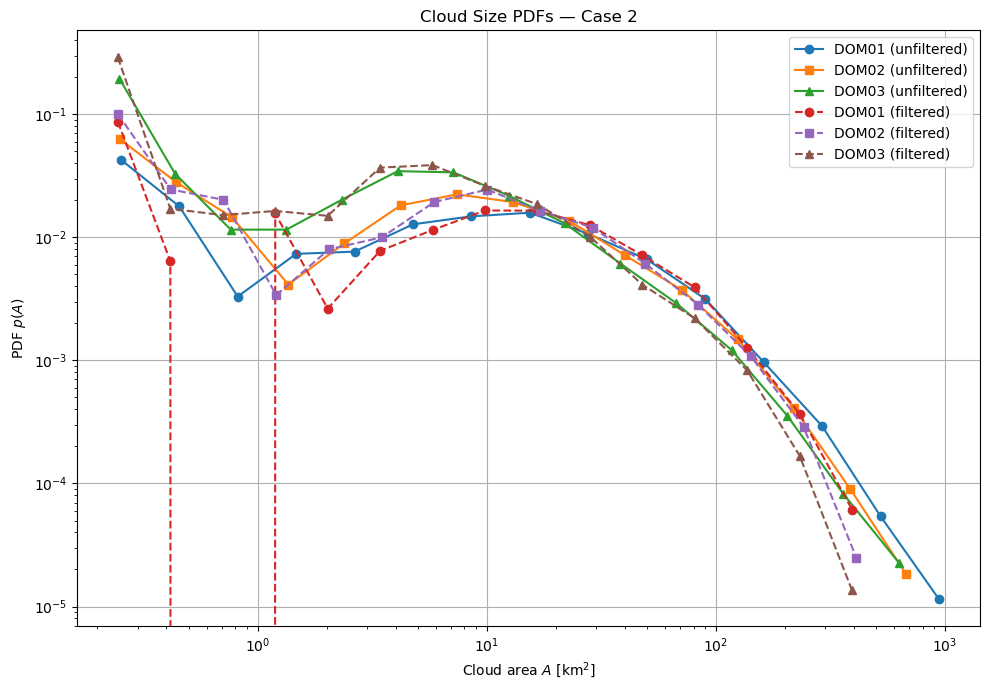

In [8]:
plt.figure(figsize=(10, 7))

# --- Unfiltered ---
sizes_dom1 = extract_sizes(Features_fields, "case2", "DOM01")
sizes_dom2 = extract_sizes(Features_fields, "case2", "DOM02")
sizes_dom3 = extract_sizes(Features_fields, "case2", "DOM03")

bc1, pdf1 = compute_pdf_logbins(sizes_dom1, nbins=15)
bc2, pdf2 = compute_pdf_logbins(sizes_dom2, nbins=15)
bc3, pdf3 = compute_pdf_logbins(sizes_dom3, nbins=15)

plt.loglog(bc1, pdf1, 'o-', label="DOM01 (unfiltered)")
plt.loglog(bc2, pdf2, 's-', label="DOM02 (unfiltered)")
plt.loglog(bc3, pdf3, '^-', label="DOM03 (unfiltered)")

# --- Filtered ---
sizes_dom1_filt = extract_sizes(Features_fields_filtered, "case2", "DOM01")
sizes_dom2_filt = extract_sizes(Features_fields_filtered, "case2", "DOM02")
sizes_dom3_filt = extract_sizes(Features_fields_filtered, "case2", "DOM03")

bc1f, pdf1f = compute_pdf_logbins(sizes_dom1_filt, nbins=15)
bc2f, pdf2f = compute_pdf_logbins(sizes_dom2_filt, nbins=15)
bc3f, pdf3f = compute_pdf_logbins(sizes_dom3_filt, nbins=15)

plt.loglog(bc1f, pdf1f, 'o--', label="DOM01 (filtered)")
plt.loglog(bc2f, pdf2f, 's--', label="DOM02 (filtered)")
plt.loglog(bc3f, pdf3f, '^--', label="DOM03 (filtered)")

# Labels & legend
plt.xlabel("Cloud area $A$ [km$^2$]")
plt.ylabel("PDF $p(A)$")
plt.title("Cloud Size PDFs — Case 2")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


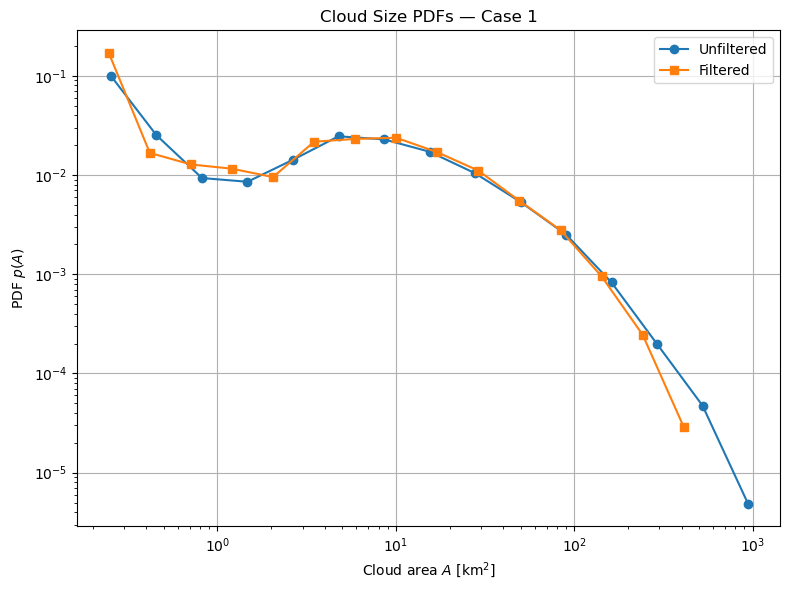

In [9]:
"""
Plot log-binned PDFs of cloud areas for one case across all domains.
Compares original vs boundary-filtered segmentation results.
"""

case_name = "case2"
domains = Features_fields[case_name].keys()

# 1. Extract all area values from both original and filtered
all_areas_unfiltered = []
all_areas_filtered = []

for dom in domains:
    df_orig = Features_fields[case_name][dom]
    all_areas_unfiltered.extend(df_orig["size_km2"].values)

    if case_name in Features_fields_filtered and dom in Features_fields_filtered[case_name]:
        df_filt = Features_fields_filtered[case_name][dom]
        all_areas_filtered.extend(df_filt["size_km2"].values)

all_areas_unfiltered = np.asarray(all_areas_unfiltered)
all_areas_filtered   = np.asarray(all_areas_filtered)



bc_unfilt, pdf_unfilt = compute_pdf_logbins(all_areas_unfiltered, nbins=15)
bc_filt, pdf_filt = compute_pdf_logbins(all_areas_filtered, nbins=15)



# 2. Plotting
plt.figure(figsize=(8,6))
plt.loglog(bc_unfilt, pdf_unfilt, marker='o', label="Unfiltered")
plt.loglog(bc_filt, pdf_filt, marker='s', label="Filtered")

plt.xlabel("Cloud area $A$ [km$^2$]")
plt.ylabel("PDF $p(A)$")
plt.title("Cloud Size PDFs — Case 1")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

1994
1498
4949
3224


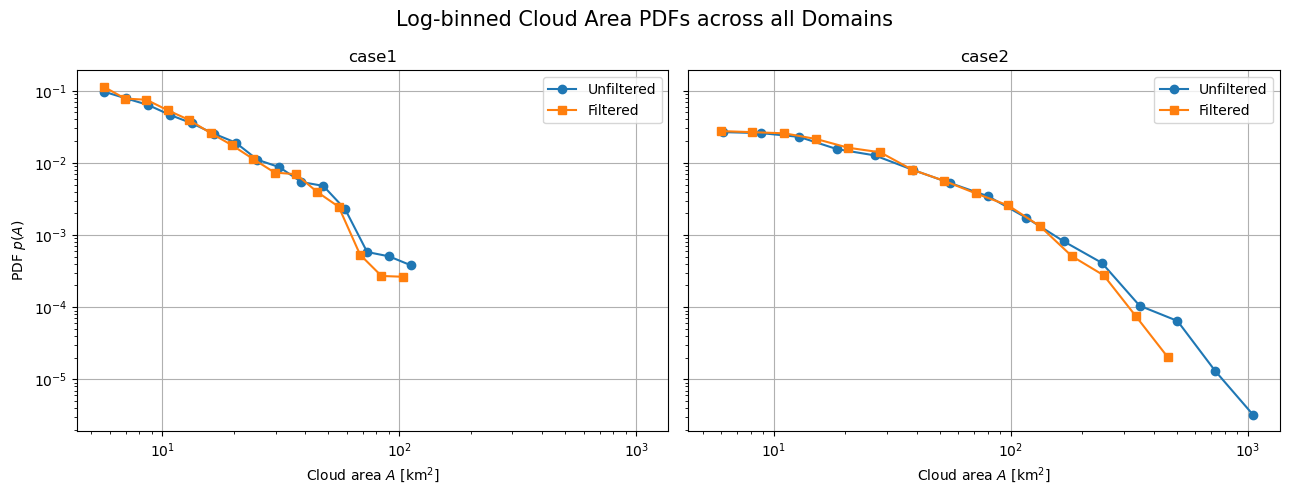

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
fig.suptitle("Log-binned Cloud Area PDFs across all Domains", fontsize=15)

for i, case_name in enumerate(["case1", "case2"]):
    domains = Features_fields[case_name].keys()

    # 1. Collect areas
    all_areas_unfiltered = []
    all_areas_filtered   = []

    for dom in domains:
        df_orig = Features_fields[case_name][dom]
        all_areas_unfiltered.extend(df_orig["size_km2"].values)

        if case_name in Features_fields_filtered and dom in Features_fields_filtered[case_name]:
            df_filt = Features_fields_filtered[case_name][dom]
            all_areas_filtered.extend(df_filt["size_km2"].values)

    all_areas_unfiltered = np.asarray(all_areas_unfiltered)
    all_areas_filtered   = np.asarray(all_areas_filtered)
    print(len(all_areas_unfiltered))
    print(len(all_areas_filtered))
    #filter out small an big clouds
    all_areas_unfiltered = all_areas_unfiltered[all_areas_unfiltered > 5]
    all_areas_filtered   = all_areas_filtered[all_areas_filtered > 5]
    #all_areas_unfiltered = all_areas_unfiltered[all_areas_unfiltered < 150]
    #all_areas_filtered   = all_areas_filtered[all_areas_filtered < 150]


    # 2. Compute PDFs
    bc_unfilt, pdf_unfilt = compute_pdf_logbins(all_areas_unfiltered, nbins=15)
    bc_filt, pdf_filt     = compute_pdf_logbins(all_areas_filtered, nbins=15)

    # 3. Plot
    ax = axes[i]
    ax.loglog(bc_unfilt, pdf_unfilt, marker='o', label="Unfiltered")
    ax.loglog(bc_filt, pdf_filt, marker='s', label="Filtered")
    ax.set_title(f"{case_name}")
    ax.set_xlabel("Cloud area $A$ [km$^2$]")
    if i == 0:
        ax.set_ylabel("PDF $p(A)$")
    ax.grid(True)
    
    #plot reference 
    #bin_centers = bc_filt
    #beta = 1.33
    #A0 = np.median(bin_centers)
    #p0 = 0.02 # pick by try and error
    #ref = p0 * (bin_centers / A0)**(-beta)
    #ax.loglog(bin_centers, ref, '--', label=r'ref: $A^{-1.33}$')

    ax.legend()

plt.tight_layout()
plt.show()


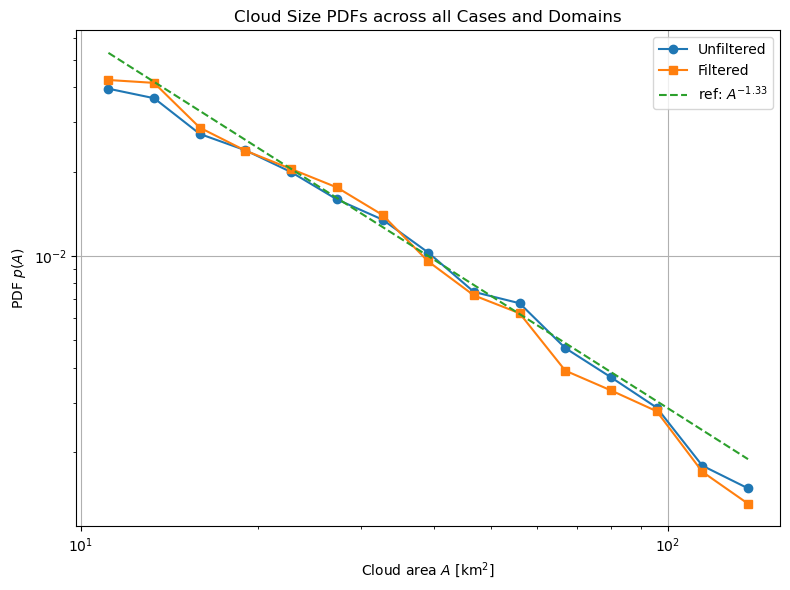

In [36]:
all_areas_unfiltered = []
all_areas_filtered   = []

for i, case_name in enumerate(["case1", "case2"]):
    domains = Features_fields[case_name].keys()

    # 1. Collect areas

    for dom in domains:
        df_orig = Features_fields[case_name][dom]
        all_areas_unfiltered.extend(df_orig["size_km2"].values)

        if case_name in Features_fields_filtered and dom in Features_fields_filtered[case_name]:
            df_filt = Features_fields_filtered[case_name][dom]
            all_areas_filtered.extend(df_filt["size_km2"].values)

all_areas_unfiltered = np.asarray(all_areas_unfiltered)
all_areas_filtered   = np.asarray(all_areas_filtered)


#filter out small an big clouds
all_areas_unfiltered = all_areas_unfiltered[(all_areas_unfiltered > 10) & (all_areas_unfiltered < 150)]
all_areas_filtered   = all_areas_filtered[(all_areas_filtered > 10) & (all_areas_filtered < 150)]

# 2. Compute PDFs
bc_unfilt, pdf_unfilt = compute_pdf_logbins(all_areas_unfiltered, nbins=15)
bc_filt, pdf_filt     = compute_pdf_logbins(all_areas_filtered, nbins=15)

# 3. Plot
plt.figure(figsize=(8,6))
plt.loglog(bc_unfilt, pdf_unfilt, marker='o', label="Unfiltered")
plt.loglog(bc_filt, pdf_filt, marker='s', label="Filtered")

plt.xlabel("Cloud area $A$ [km$^2$]")
plt.ylabel("PDF $p(A)$")
plt.title("Cloud Size PDFs across all Cases and Domains")
plt.legend()
plt.grid(True)

#plot reference 
bin_centers = bc_filt
beta = 1.33
A0 = np.median(bin_centers)
p0 = 0.01 # pick by try and error
ref = p0 * (bin_centers / A0)**(-beta)
plt.loglog(bin_centers, ref, '--', label=r'ref: $A^{-1.33}$')
plt.legend()

plt.tight_layout()
plt.show()


# Pair Correlation Funktion (PCF)

In [19]:
def compute_random_reference(domain_shape, N_obj, r_bins):
    """Simulate random points and compute reference pairwise distance histogram."""
    x_min, x_max = 0, domain_shape[0]   
    y_min, y_max = 0, domain_shape[1]

    x_points = np.random.uniform(x_min, x_max, N_obj)
    y_points = np.random.uniform(y_min, y_max, N_obj)
    random_positions = np.stack([x_points, y_points], axis=1)

    dists_random = pdist(random_positions)
    counts_random, _ = np.histogram(dists_random, bins=r_bins)
    return counts_random


def compute_avg_pairwise_counts(df, r_bins):
    """Compute average pairwise distance histogram across all timestamps."""
    total_counts = np.zeros(len(r_bins) - 1)
    valid_snapshots = 0

    for timestamp in df["time"].unique():
        df_at_time = df[df["time"] == timestamp]
        positions = df_at_time[["hdim_1", "hdim_2"]].to_numpy()
        if positions.shape[0] < 2:
            continue
        dists = pdist(positions)
        counts, _ = np.histogram(dists, bins=r_bins)
        total_counts += counts
        valid_snapshots += 1

    avg_counts = total_counts / valid_snapshots if valid_snapshots > 0 else total_counts
    return avg_counts

def compute_avg_pairwise_counts_all_domains(case_name, Features_fields, Mask_fields, r_bins):
    total_counts = np.zeros(len(r_bins) - 1)
    valid_snapshots = 0

    for dom in Features_fields[case_name]:
        df = Features_fields[case_name][dom]
        for timestamp in df["time"].unique():
            df_at_time = df[df["time"] == timestamp]
            positions = df_at_time[["hdim_1", "hdim_2"]].to_numpy()
            if positions.shape[0] < 2:
                continue
            dists = pdist(positions)
            counts, _ = np.histogram(dists, bins=r_bins)
            total_counts += counts
            valid_snapshots += 1

    avg_counts = total_counts / valid_snapshots if valid_snapshots > 0 else total_counts
    return avg_counts


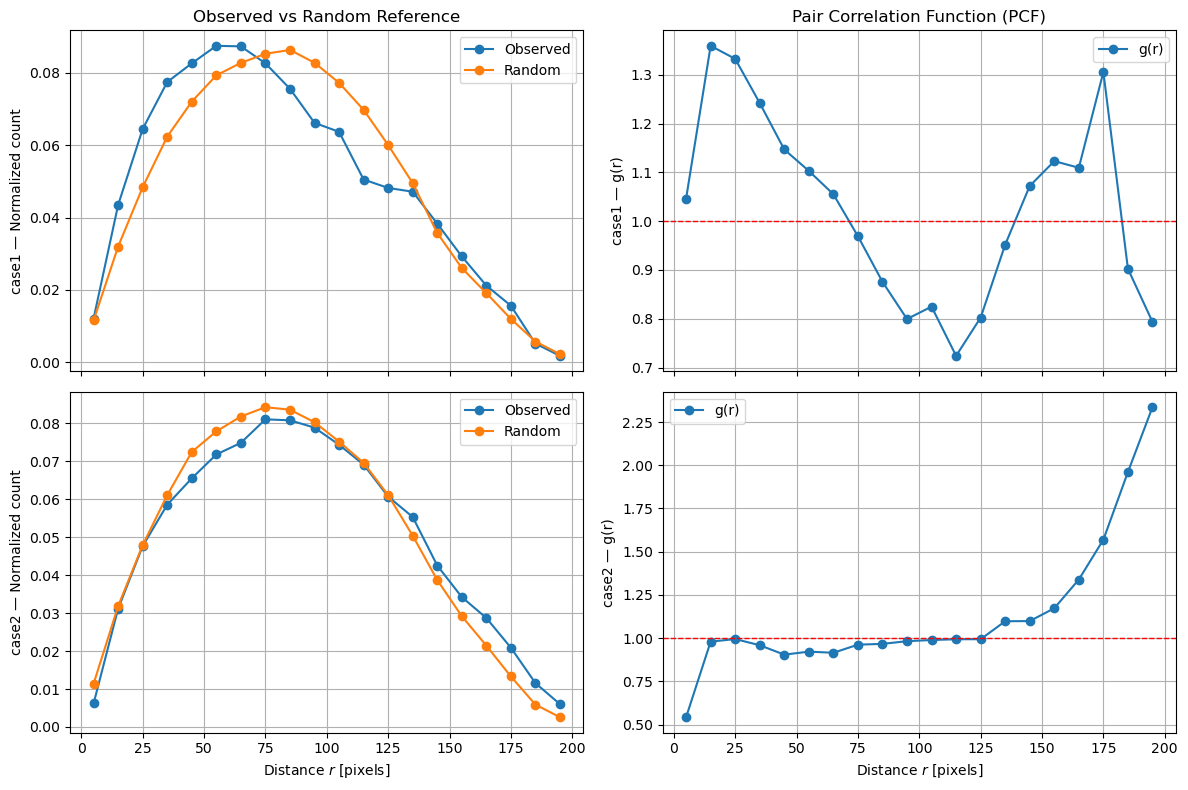

In [37]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
r_bins = np.linspace(0, 200, 21)
r_centers = (r_bins[:-1] + r_bins[1:]) / 2
cases = ["case1", "case2"]
N_obj = 1000  # number of random points for reference

for i, case_name in enumerate(cases):
    # Compute observed counts averaged over all domains
    counts_obs = compute_avg_pairwise_counts_all_domains(case_name, Features_fields, Mask_fields, r_bins)

    # Use one domain’s shape for reference generation
    example_dom = next(iter(Mask_fields[case_name]))
    mask = Mask_fields[case_name][example_dom]
    domain_shape = (mask.sizes["lon"], mask.sizes["lat"])
    counts_rand = compute_random_reference(domain_shape, N_obj, r_bins)

    # Normalize
    norm_obs = counts_obs / counts_obs.sum() if counts_obs.sum() > 0 else counts_obs
    norm_rand = counts_rand / counts_rand.sum() if counts_rand.sum() > 0 else counts_rand
    g_r = norm_obs / norm_rand

    # --- Left plot: counts ---
    axs[i, 0].plot(r_centers, norm_obs, label='Observed', marker='o')
    axs[i, 0].plot(r_centers, norm_rand, label='Random', marker='o')
    axs[i, 0].set_ylabel(f"{case_name} — Normalized count")
    axs[i, 0].legend()
    axs[i, 0].grid(True)

    # --- Right plot: PCF ---
    axs[i, 1].plot(r_centers, g_r, marker='o', label='g(r)')
    axs[i, 1].axhline(1, color='red', linestyle='--', linewidth=1)
    axs[i, 1].set_ylabel(f"{case_name} — g(r)")
    axs[i, 1].legend()
    axs[i, 1].grid(True)

# Common labels
for ax in axs[-1]:
    ax.set_xlabel("Distance $r$ [pixels]")

axs[0, 0].set_title("Observed vs Random Reference")
axs[0, 1].set_title("Pair Correlation Function (PCF)")

plt.tight_layout()
plt.show()


# Convective Organization Potential(COP):

White et al. (2018)...
  
For a single scene (one timestep), we consider:  
  
- Total number of objects: $ N $  
- Object area: $ A_i $  (from TOBAC `ncells` as area $A_i$ (pixel counts))
- Object centroid coordinates: $ (x_i, y_i)$ (from TOBAC `hdim_1`, `hdim_2` as centroid coordinates (pixel space))
  
Each object is approximated as a circle of equal area:  
$$  
r_i = \sqrt{\frac{A_i}{\pi}}  
$$  
For each pair of objects $ i < j $, define the interaction potential:  
$$  
V(i,j) = \frac{r_i + r_j}{d_{ij}}  
$$   
Equivalently, written directly in terms of object areas:  
$$  
V(i,j) = \frac{\sqrt{A_i} + \sqrt{A_j}}{d_{ij} \sqrt{\pi}}  
$$  
The total number of unique object pairs is:   
$$  
\frac{1}{2} N (N - 1)  
$$  
The Convective Organization Potential (COP) is defined as the mean interaction potential over all unique pairs:  
$$  
\mathrm{COP} =  
\frac{  
\sum_{i=1}^{N}  
\sum_{j=i+1}^{N}  
V(i,j)  
}{  
\frac{1}{2} N (N-1)  
}  
$$  
Since the denominator equals the number of pairs, COP is simply:  
$$  
\mathrm{COP} = \text{mean}\left( V(i,j) \right)  
$$


A higher COP value indicates that large convective cells are packed close together (tightly clustered), which corresponds to a greater degree of organization.


In [22]:
def cop_one_frame(df_t, eps=1e-12):
    """
    COP (White et al. style) for a single scene/frame.

    Uses:
      - centroid coords: hdim_1, hdim_2
      - area: ncells  (pixels)
      - pair distances: pdist

    Returns:
      float COP, or np.nan if N < 2
    """
    N = len(df_t)
    if N < 2:
        return np.nan
        
    # centroids in pixel space
    xy = df_t[["hdim_1", "hdim_2"]].to_numpy(dtype=float) 

    # areas in pixels -> radii in pixels
    A  = df_t["ncells"].to_numpy(dtype=float)
    r = np.sqrt(A / np.pi)

    # pairwise distances (condensed form, length = N*(N-1)/2)
    d = pdist(xy, metric="euclidean")
    d = np.maximum(d, eps)

    # pairwise (r_i + r_j) in the same condensed order as pdist
    i, j = np.triu_indices(N, k=1) #np.triu_indices(N, k=1) gives the right (i,j) pairs order
    rsum = r[i] + r[j]

    V = rsum / d
    return V.mean()

def cop_timeseries(df, group_key="frame"):
    """
    Compute COP for each frame in a feature dataframe.
    Returns a DataFrame with one row per frame.
    """
    rows = []
    for key, df_t in df.groupby(group_key, sort=True):
        rows.append({
            group_key: key,
            "time": df_t["time"].iloc[0],
            "N_objects": len(df_t),
            "COP": cop_one_frame(df_t),
        })
    return pd.DataFrame(rows).sort_values(group_key).reset_index(drop=True)


In [24]:
#Sanity check
df = Features_fields_filtered["case1"]["DOM01"]
df_t = df[df["frame"] == 0] #df_t contains only one frame

df_t2 = df_t.copy()
df_t2["hdim_1"] *= 2
df_t2["hdim_2"] *= 2
print("COP original:", cop_one_frame(df_t))
print("COP stretched:", cop_one_frame(df_t2))


COP original: 0.1452187794696264
COP stretched: 0.0726093897348132


In [25]:
# usage 
df = Features_fields_filtered["case1"]["DOM01"]
cop_df = cop_timeseries(df, group_key="frame")
cop_df.head()

,frame,time,N_objects,COP
0,0,2024-08-06 12:00:00,19,0.145219
1,1,2024-08-06 12:05:00,14,0.142746
2,2,2024-08-06 12:10:00,12,0.208062
3,3,2024-08-06 12:15:00,11,0.236203
4,4,2024-08-06 12:20:00,6,0.117213


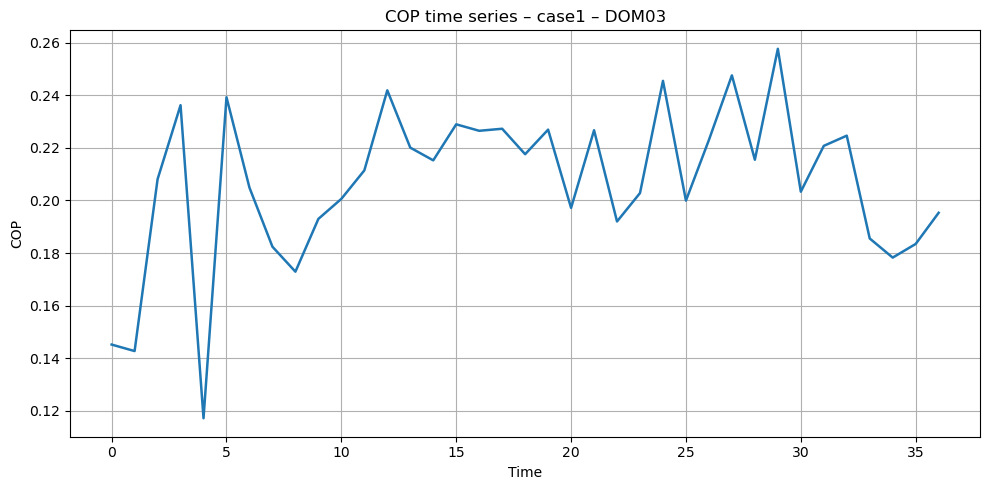

In [26]:
plt.figure(figsize=(10,5))
plt.plot(cop_df["frame"], cop_df["COP"], lw=1.8)
plt.xlabel("Time")
plt.ylabel("COP")
plt.title(f"COP time series – {case} – {dom}")
plt.grid()
plt.tight_layout()
plt.show()

## Case and domain comparison

In [73]:
cases = ["case1", "case2"]
domains = ["DOM01", "DOM02", "DOM03"]

cop_all = {}

for case in cases:
    cop_all[case] = {}
    for dom in domains:
        df = Features_fields_filtered[case][dom]
        #df = Features_fields[case][dom]
        cop_df = cop_timeseries(df)
        cop_all[case][dom] = cop_df[["time", "COP"]].rename(
            columns={"COP": f"COP_{dom}"}
        )


cop_compare = {}

for case in cases:
    df_merge = cop_all[case]["DOM01"]

    for dom in ["DOM02", "DOM03"]:
        df_merge = df_merge.merge(
            cop_all[case][dom],
            on="time",
            how="inner"
        )

    cop_compare[case] = df_merge



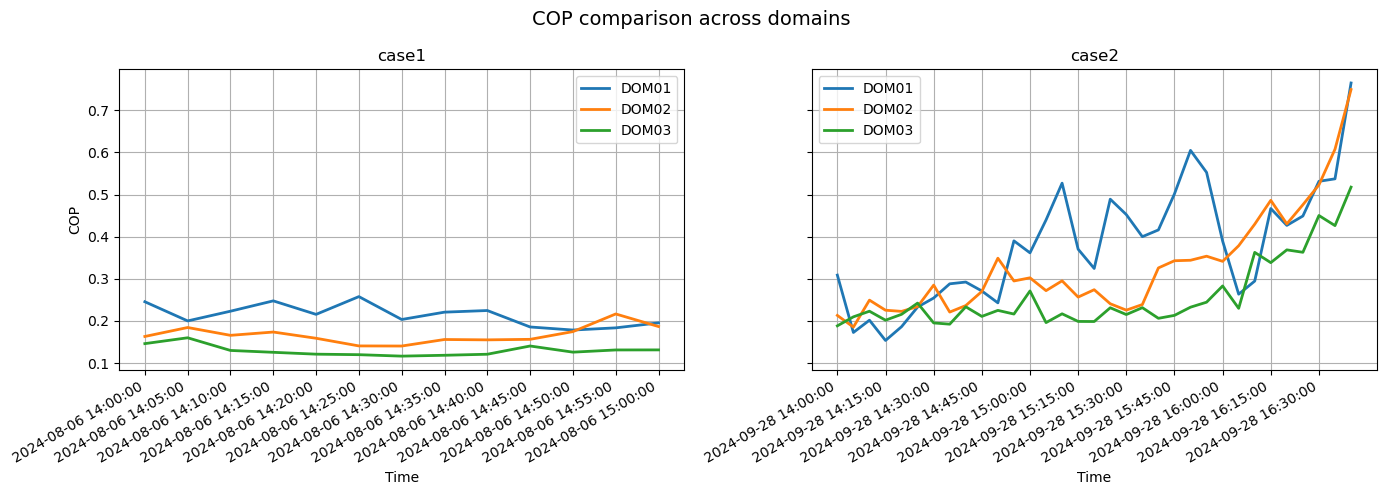

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14,5), sharey=True)

for ax, case in zip(axes, cases):
    df_plot = cop_compare[case]

    ax.plot(df_plot["time"], df_plot["COP_DOM01"], label="DOM01", lw=2)
    ax.plot(df_plot["time"], df_plot["COP_DOM02"], label="DOM02", lw=2)
    ax.plot(df_plot["time"], df_plot["COP_DOM03"], label="DOM03", lw=2)

    ax.set_title(case)
    ax.set_xlabel("Time")
    ax.grid()


axes[0].set_ylabel("COP")
axes[0].legend()
axes[1].legend()

fig.suptitle("COP comparison across domains", fontsize=14)

axes[1].set_xticks(axes[1].get_xticks()[::3])# keep every 3rd tick

#fixing spacing & rotation of date/time
fig.autofmt_xdate()   
plt.tight_layout()
plt.show()


In [77]:
#comparison between filtered and not filtered
cases = ["case1", "case2"]
domains = ["DOM01", "DOM02", "DOM03"]

datasets = {
    "filtered": Features_fields_filtered,
    "unfiltered": Features_fields,   # <- your non-filtered dict
}

cop_compare = {ds_name: {} for ds_name in datasets}

for ds_name, DS in datasets.items():
    cop_all = {}

    for case in cases:
        cop_all[case] = {}
        for dom in domains:
            df = DS[case][dom]
            cop_df = cop_timeseries(df)  # expects columns: time, COP (and frame etc.)
            cop_all[case][dom] = cop_df[["time", "COP"]].rename(columns={"COP": f"COP_{dom}"})

    # merge DOM01/02/03 on time for each case
    for case in cases:
        df_merge = cop_all[case]["DOM01"]
        for dom in ["DOM02", "DOM03"]:
            df_merge = df_merge.merge(cop_all[case][dom], on="time", how="inner")
        cop_compare[ds_name][case] = df_merge

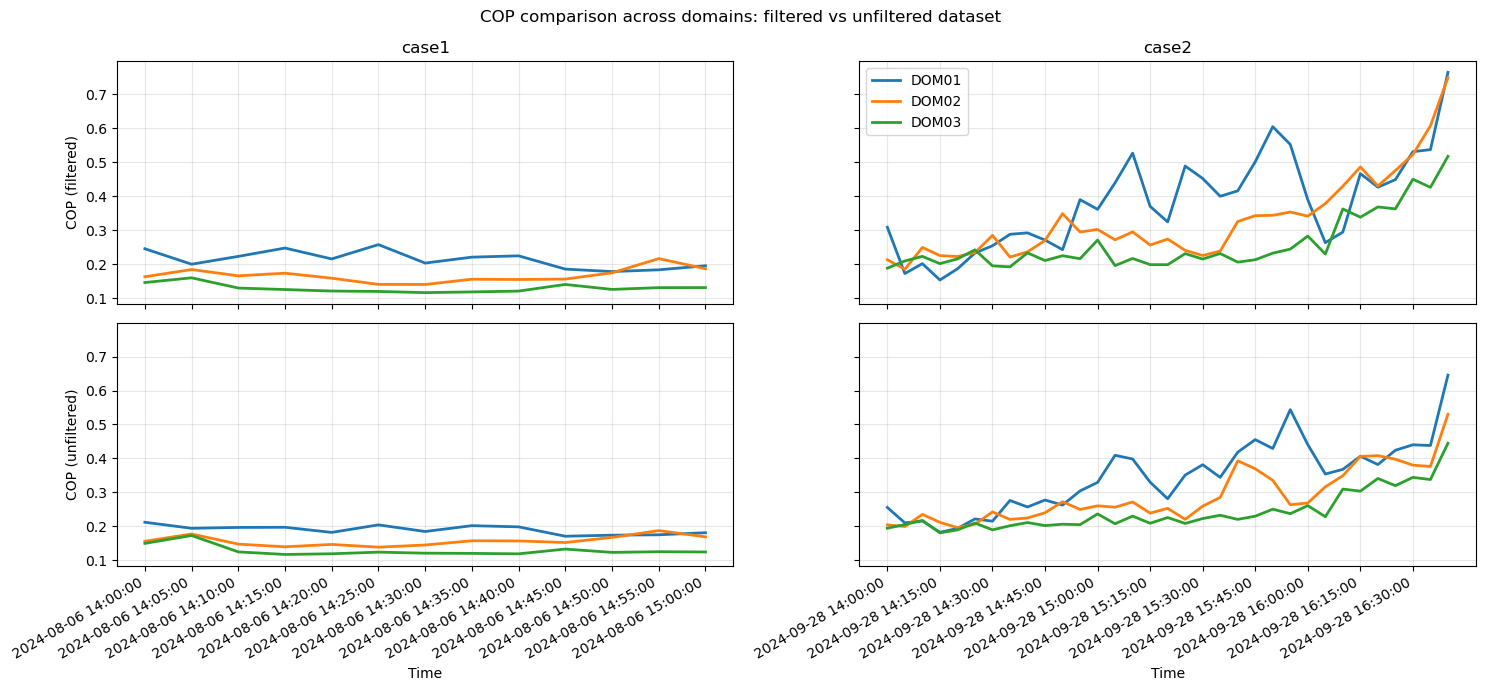

In [79]:


fig, axes = plt.subplots(
    2, 2, figsize=(15, 7),
    sharex="col", sharey=True
)

row_names = ["filtered", "unfiltered"]
col_cases = ["case1", "case2"]

for r, ds_name in enumerate(row_names):
    for c, case in enumerate(col_cases):
        ax = axes[r, c]
        df_plot = cop_compare[ds_name][case]

        ax.plot(df_plot["time"], df_plot["COP_DOM01"], label="DOM01", lw=2)
        ax.plot(df_plot["time"], df_plot["COP_DOM02"], label="DOM02", lw=2)
        ax.plot(df_plot["time"], df_plot["COP_DOM03"], label="DOM03", lw=2)

        if r == 0:
            ax.set_title(case)
        if c == 0:
            ax.set_ylabel(f"COP ({ds_name})")

        ax.grid(alpha=0.3)

# one legend for all panels
axes[0, 1].legend(loc="upper left")

for ax in axes[-1, :]:
    ax.set_xlabel("Time")
    
axes[1, 1].set_xticks(axes[1, 1].get_xticks()[::3])# keep every 3rd tick

fig.suptitle("COP comparison across domains: filtered vs unfiltered dataset")

fig.autofmt_xdate()   # rotates/spacing of datetime labels
plt.tight_layout()
plt.show()